### Parametres

In [54]:
from functools import partial
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import torch

import vt_all_solvers_wrapper as vt
import dataset
import utils
import models.mlp as mlp_module
import models.fno as fno_module
import models.deep as deep_module

importlib.reload(vt)
importlib.reload(dataset)
importlib.reload(utils)
importlib.reload(mlp_module)
importlib.reload(fno_module)
importlib.reload(deep_module)

import base_range_library 
importlib.reload(base_range_library)
from base_range_library import range_library, hole_library, length_range_library

from dataset import StreamingGeometryDatasetConfig, make_streaming_dataloader
from utils import (
    DEFAULT_VALIDATION_METRICS,
    TrainConfig,
    fit,
    make_optimizer,
    mse_loss,
    plot_history,
)
from losses import UniversalTransferFunctionLoss
from models.mlp import ProfileMLP, webster_mlp_batch_to_xy
from models.fno import TransferFunctionFNO, webster_fno_batch_to_xy
from models.deep import (
    TransferFunctionDeepONet,
    TransferFunctionDynamicDeepONet,
    TransferFunctionDeformableDeepONet,
    webster_deeponet_batch_to_xy,
)

In [63]:
device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32
sections = 100
n_profile_points = 128
n_frequencies = 256

steps_per_epoch = 10
val_steps = 10
epochs = 20

# Change this to inspect another channel inside the validation batch.
preview_sample_idx = 0

loss_name = "transfer_db"  # "mse" or "transfer_db"

transfer_loss_db_kwargs = {
    "output_type": "db",

    "db_weight": 1.0,
    "magnitude_weight": 0.1,
    "db_derivative_weight": 0.02,

    "peak_weight": 0.0,
    "peak_level_weight": 0.2,

    "complex_weight": 0.0,
    "complex_derivative_weight": 0.0,
    "phase_weight": 0.0,

    "db_error_scale": 10.0,
    "db_derivative_scale": 0.01,

    "peak_temperature_db": 3.0,
    "peak_min_prominence_db": 1.0,
    "peak_min_distance_hz": 40.0,
    "peak_max_count": None,

    "min_db": -100.0,
    "eps": 1e-8,
}

solver_config = vt.SolverConfig(
    solver="cone",
    sections=sections,
    points=n_frequencies,
    f_min_hz=50.0,
    f_max_hz=5000.0,
    grid="linear",
)

train_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=1,
)

val_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=100_000,
    max_samples=batch_size * val_steps,
)

print("device:", device)


device: cuda


In [64]:
train_loader = make_streaming_dataloader(
    train_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

val_loader = make_streaming_dataloader(
    val_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

In [65]:
mlp_batch_to_xy = partial(
    webster_mlp_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
    include_x=True,
)

fno_batch_to_xy = partial(
    webster_fno_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
)

deeponet_batch_to_xy = partial(
    webster_deeponet_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
    frequency_min_hz=solver_config.f_min_hz,
    frequency_max_hz=solver_config.f_max_hz,
)

In [66]:
validation_metrics = list(DEFAULT_VALIDATION_METRICS.keys())

transfer_loss_db = UniversalTransferFunctionLoss(**transfer_loss_db_kwargs)

loss_registry = {
    "mse": mse_loss,
    "transfer_db": transfer_loss_db,
}

criterion = loss_registry[loss_name]

print("loss:", criterion)
print("validation metrics:", validation_metrics)

loss: UniversalTransferFunctionLoss()
validation metrics: ['mae', 'rmse', 'rel_l2', 'magnitude_mae_db', 'magnitude_rmse_db', 'magnitude_max_abs_error_db', 'relative_derivative_l2', 'dominant_peak_frequency_mae_hz', 'dominant_peak_level_mae_db', 'dominant_notch_frequency_mae_hz', 'dominant_notch_level_mae_db', 'relative_complex_l2_percent', 'phase_mae_degrees']


In [67]:
validation_preview_batch = lambda: utils.validation_preview_batch(val_loader)
predict_on_batch = lambda model, batch_to_xy, batch: utils.predict_on_batch(
    model,
    batch_to_xy,
    batch,
    device=device,
)
batch_geometry_to_explicit = utils.batch_geometry_to_explicit
plot_batch_geometry = utils.plot_batch_geometry
plot_model_prediction_on_channel = utils.plot_model_prediction_on_channel


### MLP

In [ ]:
mlp_checkpoint_name = "mlp_db"

mlp = ProfileMLP(
    n_profile_points=n_profile_points,
    in_channels=2,  # log(area), x
    n_frequencies=n_frequencies,
    hidden_dim=512,
    depth=4,
    dropout=0.05,
    out_channels=1,
).to(device)

mlp_optimizer = make_optimizer(
    mlp,
    lr=1e-3,
    weight_decay=1e-4,
)

mlp_history = fit(
    mlp,
    mlp_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=mlp_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=mlp_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(mlp_history)


#### Проверка MLP на одном канале

In [ ]:
utils.plot_single_model_preview(
    mlp,
    mlp_batch_to_xy,
    "MLP",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)


### FNO

In [ ]:
fno_checkpoint_name = "fno_db"

fno = TransferFunctionFNO(
    n_modes=32,
    hidden_channels=96,
    latent_dim=256,
    pooling_bins=16,
    frequency_bands=16,
    out_channels=1,
).to(device)

fno_optimizer = make_optimizer(
    fno,
    lr=5e-4,
    weight_decay=1e-4,
)

fno_history = fit(
    fno,
    fno_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=fno_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=fno_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(fno_history)


#### Проверка FNO на одном канале

In [ ]:
utils.plot_single_model_preview(
    fno,
    fno_batch_to_xy,
    "FNO",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)

### DeepONet

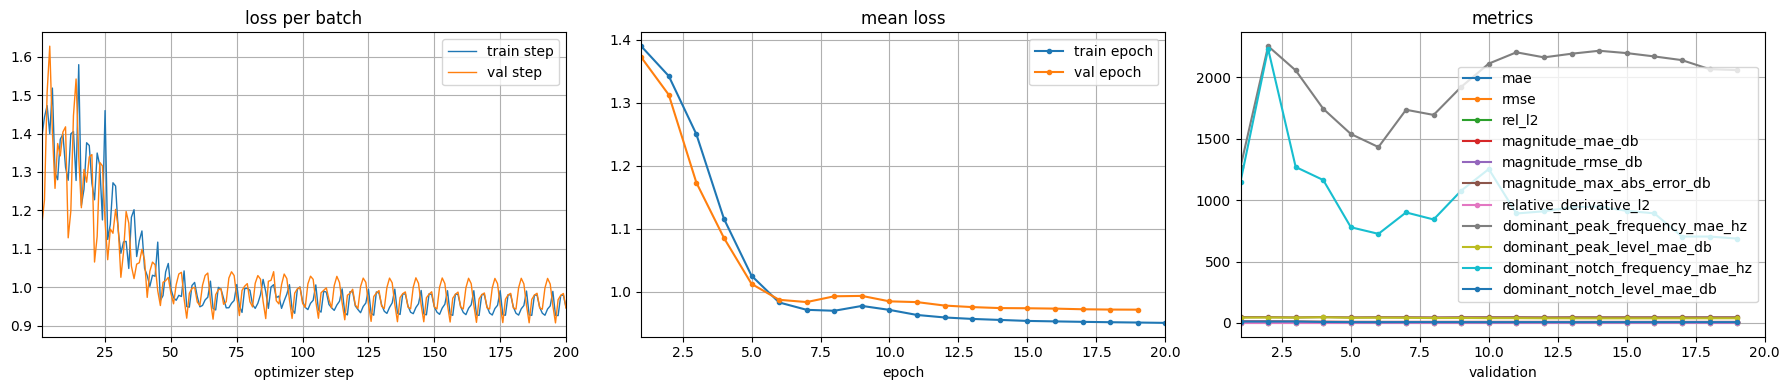

epoch 020/20 | train=0.950223 | val=0.970764 | lr=0.0005


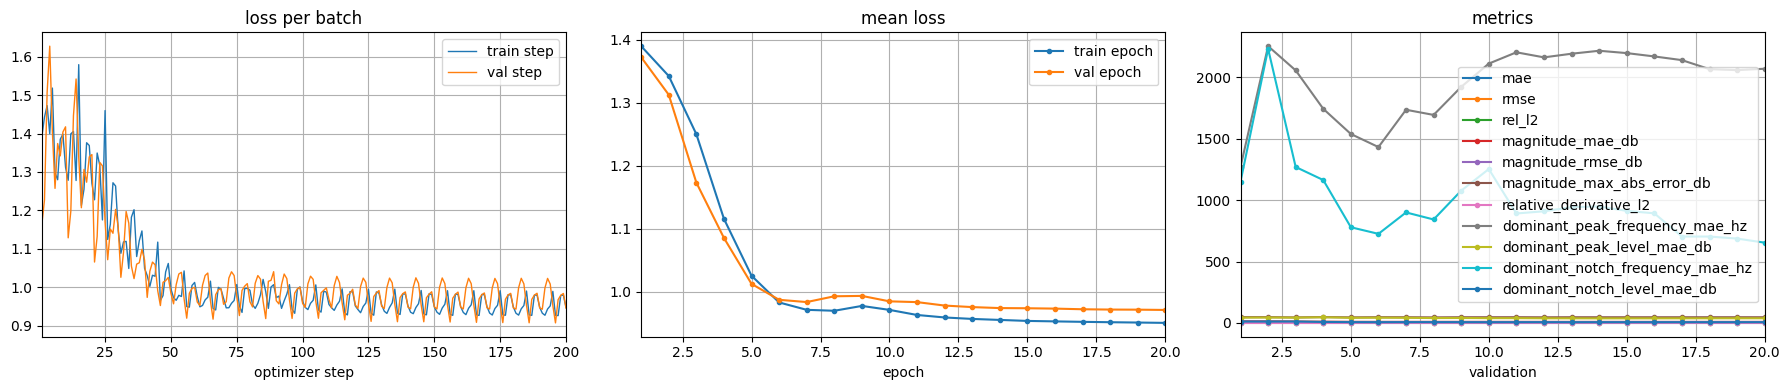

In [ ]:
deeponet_checkpoint_name = "deeponet_db"

deeponet = TransferFunctionDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
).to(device)

deeponet_optimizer = make_optimizer(
    deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

deeponet_history = fit(
    deeponet,
    deeponet_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(deeponet_history)

#### Проверка DeepONet на одном канале

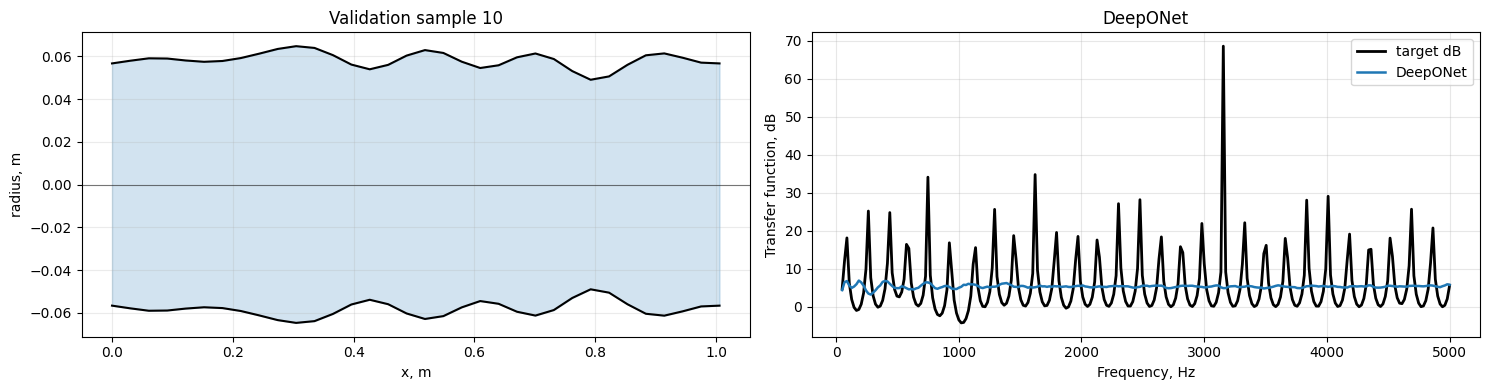

DeepONet MAE dB:  5.4658
DeepONet RMSE dB: 8.1133


In [ ]:
utils.plot_single_model_preview(
    deeponet,
    deeponet_batch_to_xy,
    "DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=10,
)

### Dynamic DeepONet


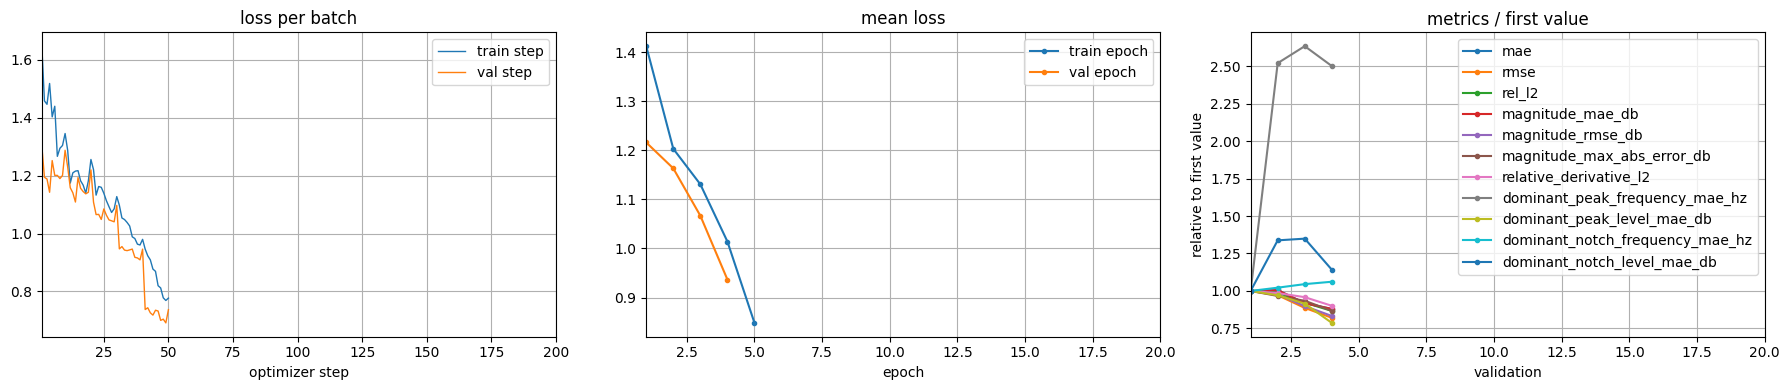

epoch 005/20 | train=0.848246 | val=0.722717 | lr=0.0005


In [ ]:
dynamic_deeponet_checkpoint_name = "dynamic_deeponet_new_db"

dynamic_deeponet = TransferFunctionDynamicDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
    n_experts=4,
    routing_hidden_dim=32,
    temperature=1.0,
).to(device)

dynamic_deeponet_optimizer = make_optimizer(
    dynamic_deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

dynamic_deeponet_history = fit(
    dynamic_deeponet,
    dynamic_deeponet_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=dynamic_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(dynamic_deeponet_history)

checkpoint: dynamic_deeponet_new_db
metrics: ['dominant_notch_level_mae_db', 'dominant_peak_level_mae_db', 'mae', 'magnitude_mae_db', 'magnitude_max_abs_error_db', 'magnitude_rmse_db', 'phase_mae_degrees', 'rel_l2', 'relative_complex_l2_percent', 'relative_derivative_l2', 'rmse']
metric not found or empty: phase_mae_degrees
metric not found or empty: relative_complex_l2_percent


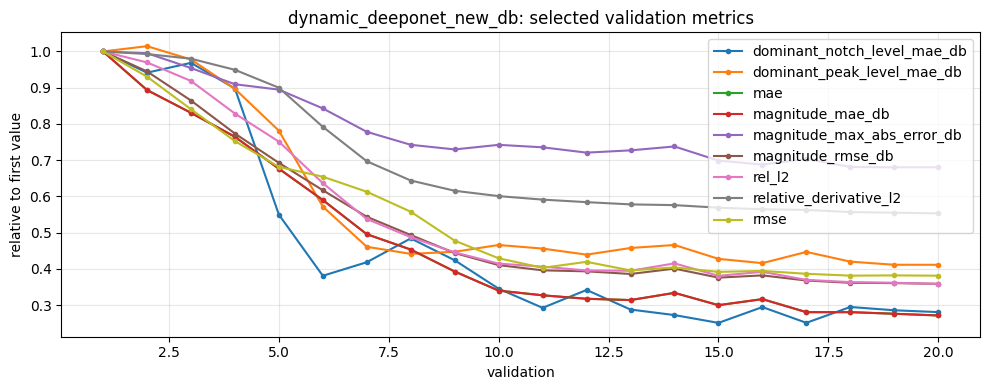

In [62]:
# Plot selected validation metrics from a saved checkpoint

metrics_checkpoint_name = "dynamic_deeponet_new_db"
metrics_normalize = True

history = utils.load_history_from_checkpoint(
    metrics_checkpoint_name,
    checkpoint_dir="checkpoints",
    map_location="cpu",
)

history_data = utils.history_to_mapping(history)
all_metric_names = sorted((history_data.get("metrics") or {}).keys())

metric_names = [
    name
    for name in all_metric_names
    if not name.endswith("_frequency_mae_hz")
]

print("checkpoint:", metrics_checkpoint_name)
print("metrics:", metric_names)

utils.plot_selected_metrics(
    history,
    metric_names,
    title=f"{metrics_checkpoint_name}: selected validation metrics",
    normalize=metrics_normalize,
)



#### Проверка Dynamic DeepONet на одном канале


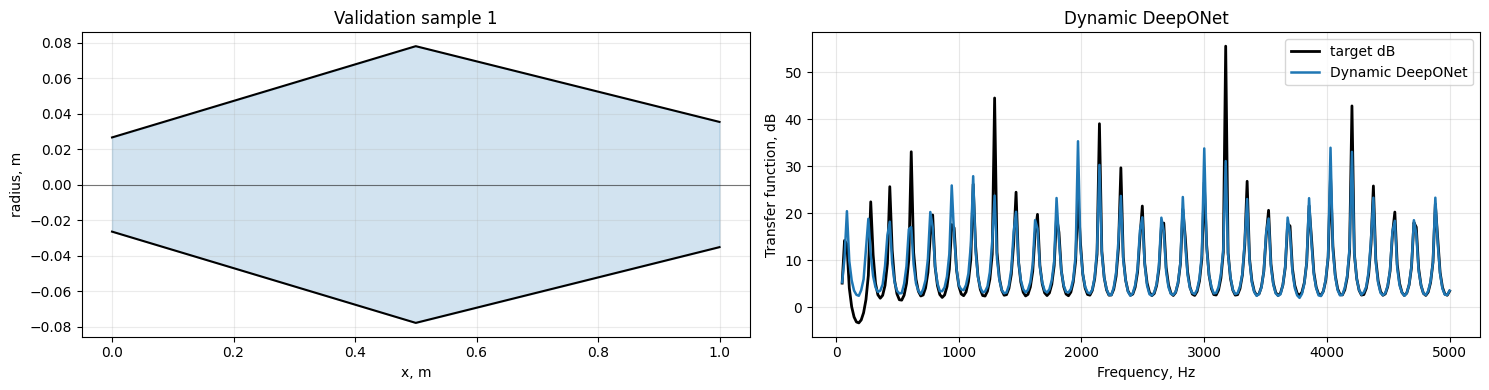

Dynamic DeepONet MAE dB:  1.6167
Dynamic DeepONet RMSE dB: 3.4141


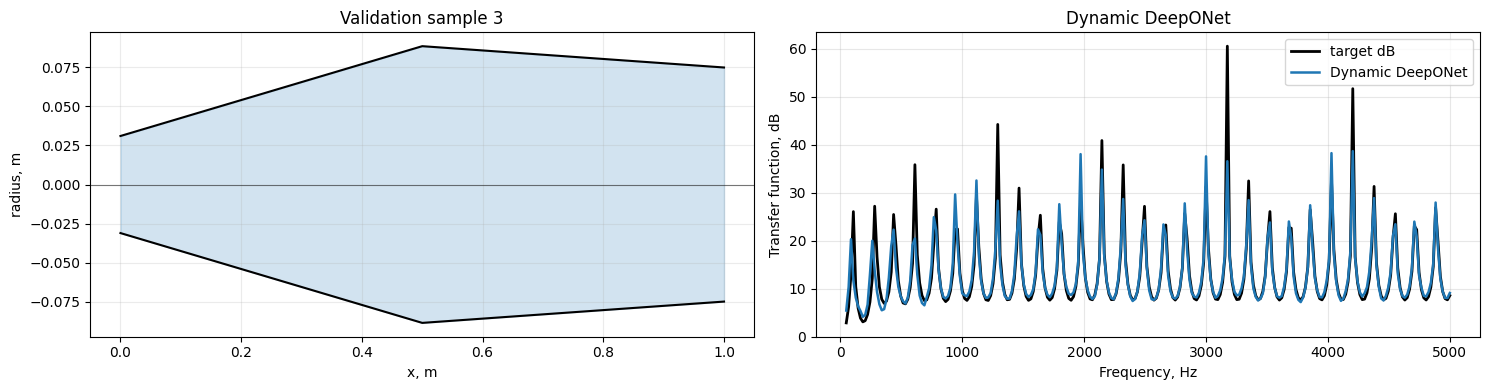

Dynamic DeepONet MAE dB:  1.5629
Dynamic DeepONet RMSE dB: 3.1907


In [ ]:
utils.plot_single_model_preview(
    dynamic_deeponet,
    deeponet_batch_to_xy,
    "Dynamic DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=1,
)
utils.plot_single_model_preview(
    dynamic_deeponet,
    deeponet_batch_to_xy,
    "Dynamic DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=3,
)

### Deformable DeepONet


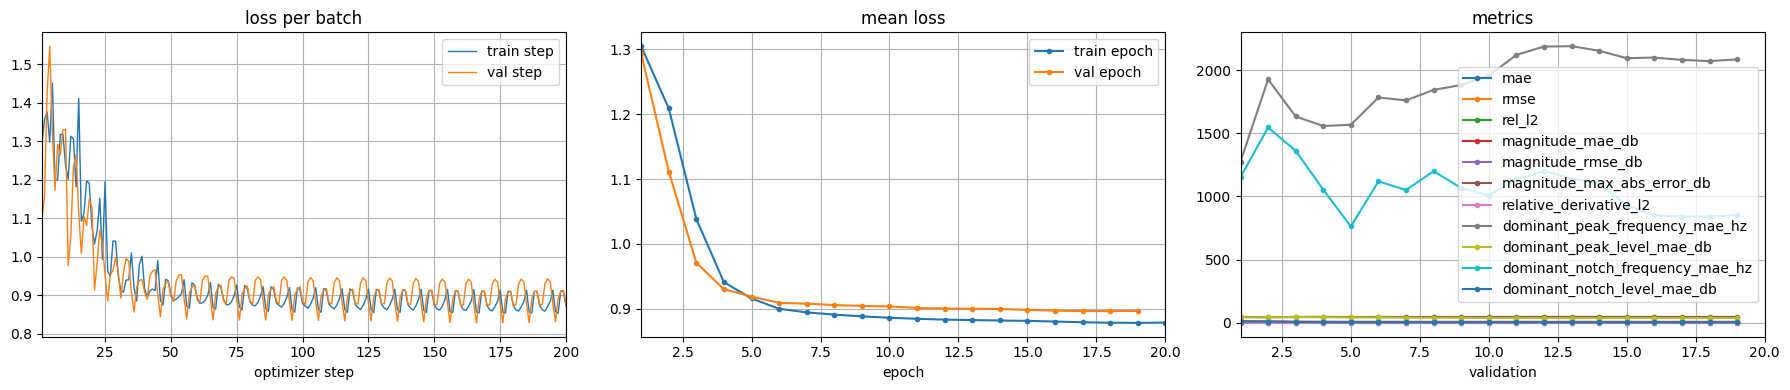

epoch 020/20 | train=0.87896 | val=0.898017 | lr=0.0005


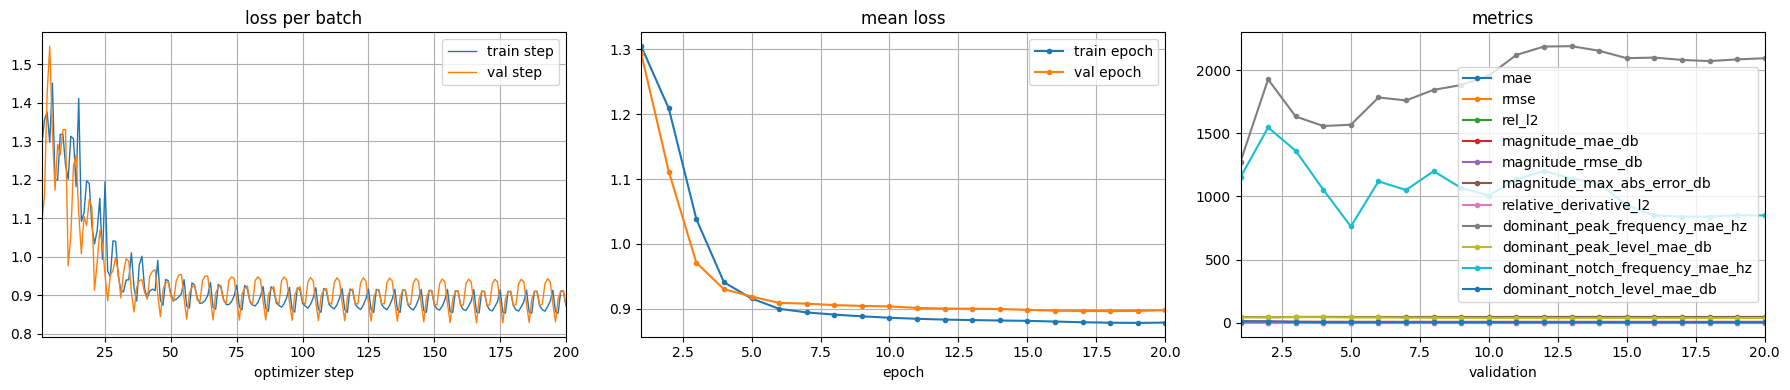

In [ ]:
deformable_deeponet_checkpoint_name = "deformable_deeponet_db"

deformable_deeponet = TransferFunctionDeformableDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
    max_offset=2.0,
    offset_hidden_channels=32,
).to(device)

deformable_deeponet_optimizer = make_optimizer(
    deformable_deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

deformable_deeponet_history = fit(
    deformable_deeponet,
    deformable_deeponet_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=TrainConfig(
        epochs=20,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=deformable_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(deformable_deeponet_history)


#### Проверка Deformable DeepONet на одном канале


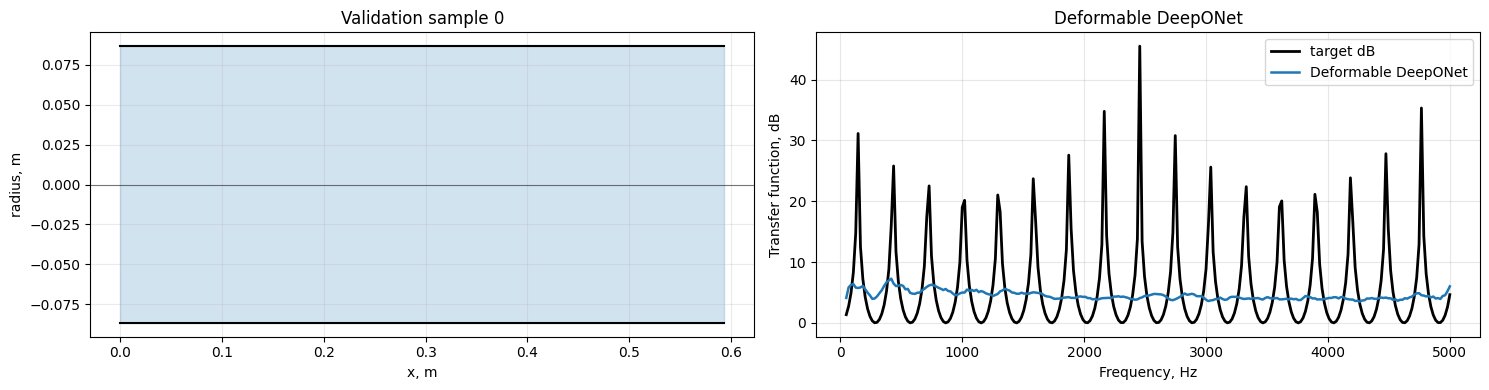

Deformable DeepONet MAE dB:  5.0793
Deformable DeepONet RMSE dB: 7.6025


In [ ]:
utils.plot_single_model_preview(
    deformable_deeponet,
    deeponet_batch_to_xy,
    "Deformable DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)

### Дообучение


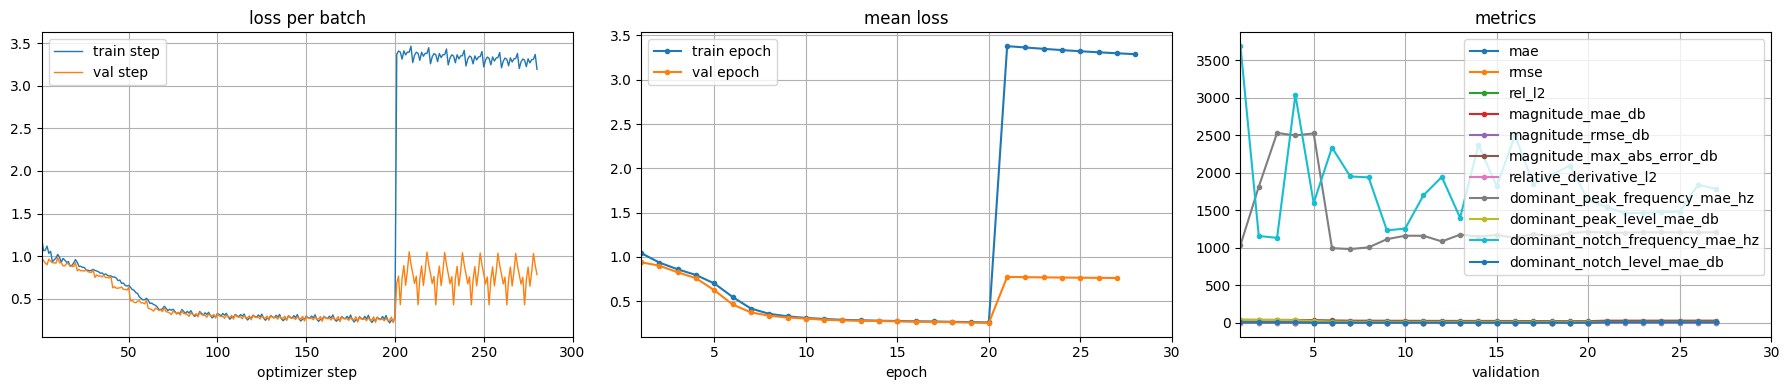

epoch 028/30 | train=3.28906 | val=0.759865 | lr=2.5e-07


KeyboardInterrupt: 

In [ ]:
importlib.reload(utils)

finetune_model_name = "deformable_deeponet_length"  # "mlp", "fno", "deeponet", "dynamic_deeponet", or "deformable_deeponet"
finetune_epochs = 10
finetune_steps_per_epoch = steps_per_epoch
finetune_val_steps = val_steps
finetune_batch_size = batch_size
finetune_lr_scale = 5e-4
finetune_resume_optimizer = True
finetune_live_plot_every_steps = 50
finetune_save_every_steps = None
finetune_checkpoint_suffix = "_finetuned"  # use "_finetuned" to keep the old best checkpoint untouched

mlp_checkpoint_name = "mlp_db"
fno_checkpoint_name = "fno_db_finetuned"
deeponet_checkpoint_name = "deeponet_db_finetuned"
dynamic_deeponet_checkpoint_name = "dynamic_deeponet_db"
deformable_deeponet_checkpoint_name = "deformable_deeponet_db"

active_library_kinds = [name for name in range_library.keys() if name != "random"]
print("active library geometry kinds:", active_library_kinds)

all_library_train_config = StreamingGeometryDatasetConfig(
    geometry_kind="tube_with_hole",  # random means: sample from every active key in range_library
    solver_config=solver_config,
    target_mode="db",
    seed=1_000_000,
)

all_library_val_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=2_000_000,
    max_samples=finetune_batch_size * finetune_val_steps,
)

all_library_train_loader = make_streaming_dataloader(
    all_library_train_config,
    range_library,
    batch_size=finetune_batch_size,
    num_workers=0,
)

all_library_val_loader = make_streaming_dataloader(
    all_library_val_config,
    range_library,
    batch_size=finetune_batch_size,
    num_workers=0,
)



def make_mlp_for_finetune():
    return ProfileMLP(
        n_profile_points=n_profile_points,
        in_channels=2,
        n_frequencies=n_frequencies,
        hidden_dim=512,
        depth=4,
        dropout=0.05,
        out_channels=1,
    )


def make_fno_for_finetune():
    return TransferFunctionFNO(
        n_modes=32,
        hidden_channels=96,
        latent_dim=256,
        pooling_bins=16,
        frequency_bands=16,
        out_channels=1,
    )


def make_deeponet_for_finetune():
    return TransferFunctionDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
    )


def make_dynamic_deeponet_for_finetune():
    return TransferFunctionDynamicDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        n_experts=4,
        routing_hidden_dim=32,
        temperature=1.0,
    )


def make_deformable_deeponet_for_finetune():
    return TransferFunctionDeformableDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        max_offset=2.0,
        offset_hidden_channels=32,
    )


finetune_specs = {
    "mlp": {
        "variable_name": "mlp",
        "history_name": "mlp_history",
        "checkpoint_name": mlp_checkpoint_name,
        "factory": make_mlp_for_finetune,
        "batch_to_xy": mlp_batch_to_xy,
        "base_lr": 1e-3,
        "weight_decay": 1e-4,
        "label": "MLP",
    },
    "fno": {
        "variable_name": "fno",
        "history_name": "fno_history",
        "checkpoint_name": fno_checkpoint_name,
        "factory": make_fno_for_finetune,
        "batch_to_xy": fno_batch_to_xy,
        "base_lr": 5e-4,
        "weight_decay": 1e-4,
        "label": "FNO",
    },
    "deeponet": {
        "variable_name": "deeponet",
        "history_name": "deeponet_history",
        "checkpoint_name": deeponet_checkpoint_name,
        "factory": make_deeponet_for_finetune,
        "batch_to_xy": deeponet_batch_to_xy,
        "base_lr": 5e-4,
        "weight_decay": 1e-4,
        "label": "DeepONet",
    },
    "dynamic_deeponet": {
        "variable_name": "dynamic_deeponet",
        "history_name": "dynamic_deeponet_history",
        "checkpoint_name": dynamic_deeponet_checkpoint_name,
        "factory": make_dynamic_deeponet_for_finetune,
        "batch_to_xy": deeponet_batch_to_xy,
        "base_lr": 5e-4,
        "weight_decay": 1e-4,
        "label": "Dynamic DeepONet",
    },
    "deformable_deeponet": {
        "variable_name": "deformable_deeponet",
        "history_name": "deformable_deeponet_history",
        "checkpoint_name": deformable_deeponet_checkpoint_name,
        "factory": make_deformable_deeponet_for_finetune,
        "batch_to_xy": deeponet_batch_to_xy,
        "base_lr": 5e-4,
        "weight_decay": 1e-4,
        "label": "Deformable DeepONet",
    },
}

if finetune_model_name not in finetune_specs:
    raise ValueError(f"finetune_model_name must be one of {sorted(finetune_specs)}")

spec = finetune_specs[finetune_model_name]
finetune_checkpoint_name = spec["checkpoint_name"] + finetune_checkpoint_suffix
source_checkpoint_path = Path("checkpoints") / f"{spec['checkpoint_name']}_best.pt"

model = globals().get(spec["variable_name"])
resume_history = globals().get(spec["history_name"])
checkpoint = None

if source_checkpoint_path.exists():
    checkpoint = torch.load(source_checkpoint_path, map_location=device)
    if model is None:
        model = spec["factory"]().to(device)
    utils.load_model_state(model, utils.checkpoint_state_dict(checkpoint), strict=True)
    checkpoint_history = checkpoint.get("history") if isinstance(checkpoint, dict) else None
    if checkpoint_history is not None:
        resume_history = checkpoint_history
    print(f"loaded checkpoint: {source_checkpoint_path}")
elif model is None:
    raise FileNotFoundError(
        f"No current {spec['variable_name']} model and no checkpoint at {source_checkpoint_path}"
    )
else:
    print(f"using current notebook model: {spec['variable_name']}")

model = model.to(device)

finetune_lr = spec["base_lr"] * finetune_lr_scale
optimizer = make_optimizer(
    model,
    lr=finetune_lr,
    weight_decay=spec["weight_decay"],
)

if (
    finetune_resume_optimizer
    and isinstance(checkpoint, dict)
    and checkpoint.get("optimizer_state") is not None
):
    try:
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        for group in optimizer.param_groups:
            group["lr"] = finetune_lr
        print("loaded optimizer state; lr reset to", finetune_lr)
    except Exception as exc:
        print("optimizer state was not loaded:", exc)

finetune_history = utils.fit(
    model,
    optimizer,
    all_library_train_loader,
    all_library_val_loader,
    criterion=criterion,
    batch_to_xy=spec["batch_to_xy"],
    config=utils.TrainConfig(
        epochs=finetune_epochs,
        steps_per_epoch=finetune_steps_per_epoch,
        val_steps=finetune_val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=finetune_live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=finetune_checkpoint_name,
        save_every_steps=finetune_save_every_steps,
        validation_metrics=validation_metrics,
    ),
    resume_history=resume_history,
)

globals()[spec["variable_name"]] = model
globals()[spec["history_name"]] = finetune_history

utils.plot_history(finetune_history)
utils.plot_single_model_preview(
    model,
    spec["batch_to_xy"],
    f"{spec['label']} after fine-tuning",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)


### Сравнение

mlp: using model from current notebook session
fno: using model from current notebook session
deeponet: loaded checkpoint checkpoints/deeponet_db_best.pt
deeponet: loaded training history from checkpoint
dynamic_deeponet: using model from current notebook session
deformable_deeponet: using model from current notebook session


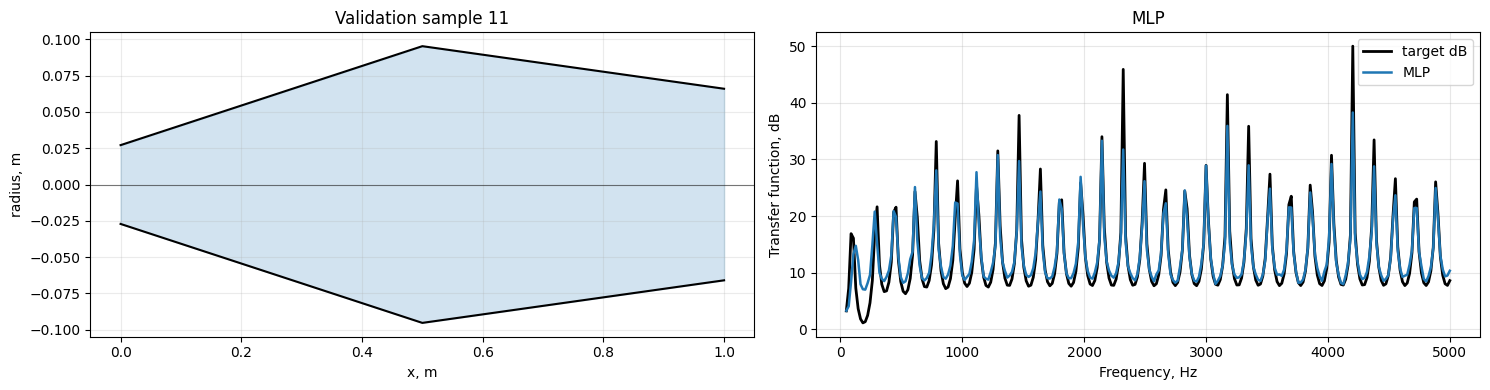

MLP MAE dB:  1.4403
MLP RMSE dB: 2.3207


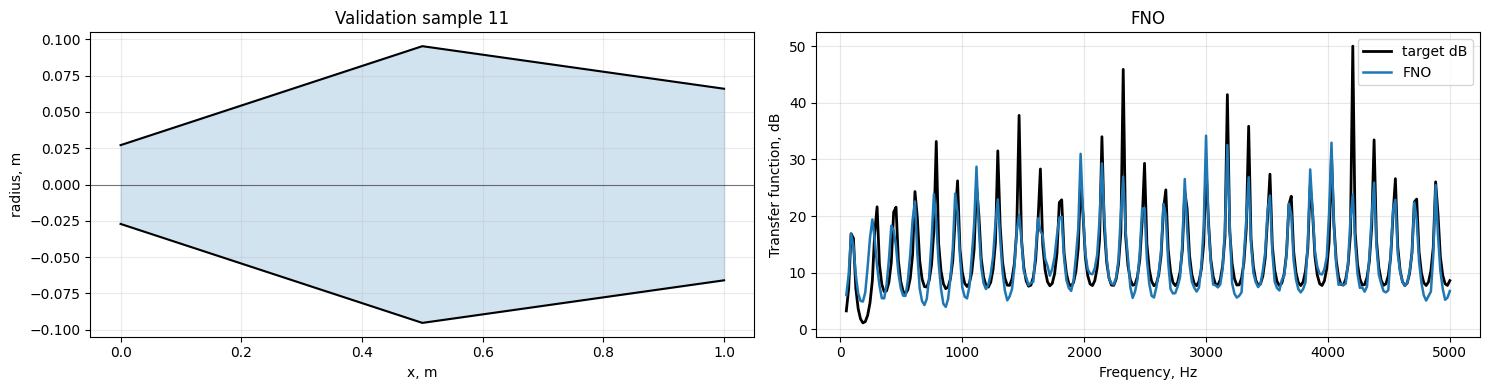

FNO MAE dB:  2.4208
FNO RMSE dB: 3.8394


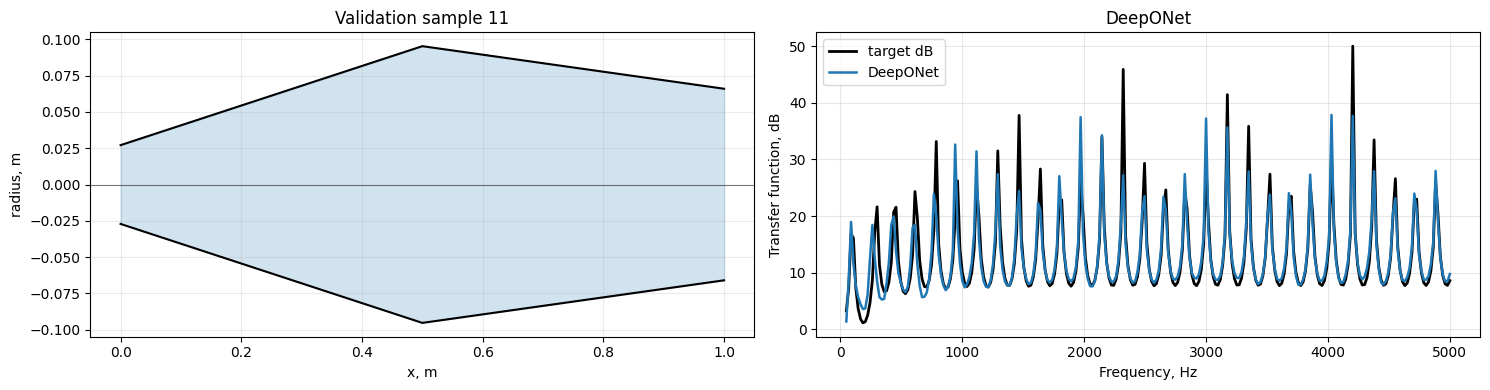

DeepONet MAE dB:  1.8531
DeepONet RMSE dB: 3.2680


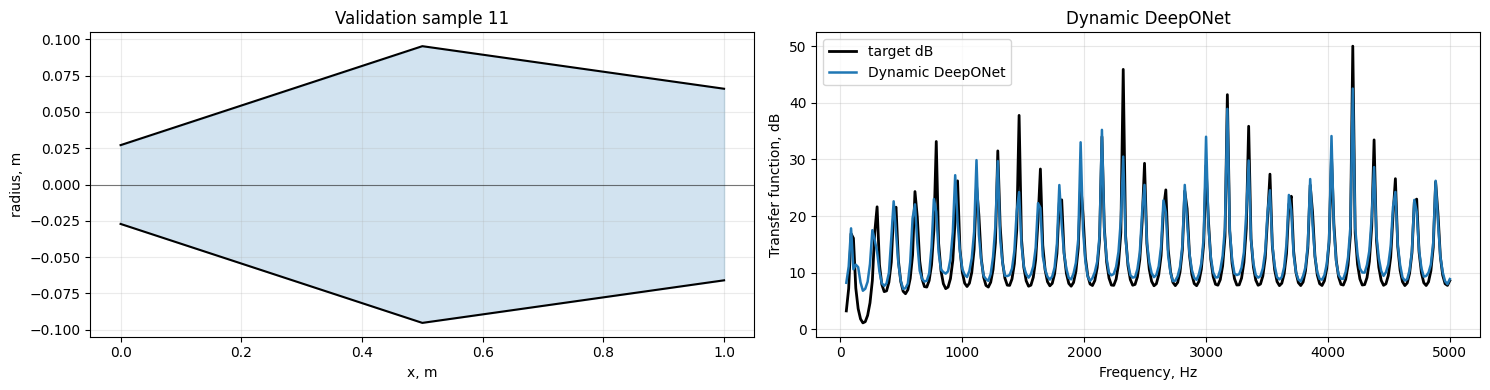

Dynamic DeepONet MAE dB:  1.9573
Dynamic DeepONet RMSE dB: 2.8844


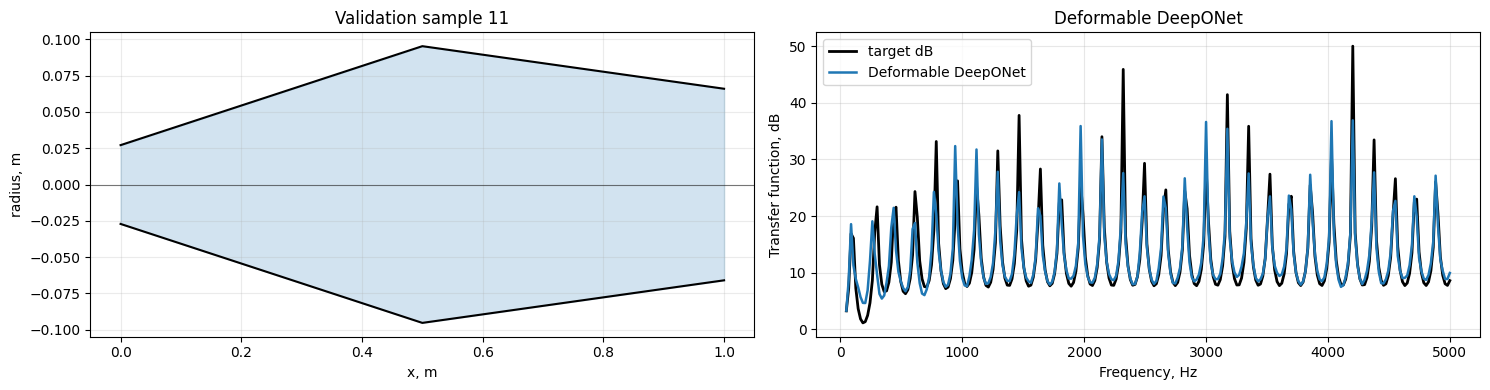

Deformable DeepONet MAE dB:  1.8706
Deformable DeepONet RMSE dB: 3.2345
=== Validation sample metrics ===
MLP      MAE dB:   1.4403 | RMSE dB:   2.3207
FNO      MAE dB:   2.4208 | RMSE dB:   3.8394
DeepONet MAE dB:   1.8531 | RMSE dB:   3.2680
Dynamic DeepONet MAE dB:   1.9573 | RMSE dB:   2.8844
Deformable DeepONet MAE dB:   1.8706 | RMSE dB:   3.2345


In [20]:
mlp_checkpoint_name = "mlp_db"
fno_checkpoint_name = "fno_db_finetuned"
deeponet_checkpoint_name = "deeponet_db"
dynamic_deeponet_checkpoint_name = "dynamic_deeponet_db"
deformable_deeponet_checkpoint_name = "deformable_deeponet_db"

comparison_sample_idx = 11
comparison_batch = validation_preview_batch()



def make_mlp_for_comparison():
    return ProfileMLP(
        n_profile_points=n_profile_points,
        in_channels=2,
        n_frequencies=n_frequencies,
        hidden_dim=512,
        depth=4,
        dropout=0.05,
        out_channels=1,
    )


def make_fno_for_comparison():
    return TransferFunctionFNO(
        n_modes=32,
        hidden_channels=96,
        latent_dim=256,
        pooling_bins=16,
        frequency_bands=16,
        out_channels=1,
    )


def make_deeponet_for_comparison():
    return TransferFunctionDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
    )


def make_dynamic_deeponet_for_comparison():
    return TransferFunctionDynamicDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        n_experts=4,
        routing_hidden_dim=32,
        temperature=1.0,
    )


def make_deformable_deeponet_for_comparison():
    return TransferFunctionDeformableDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        max_offset=2.0,
        offset_hidden_channels=32,
    )


model_specs = [
    (
        "MLP",
        "mlp",
        mlp_checkpoint_name,
        make_mlp_for_comparison,
        "mlp_history",
        mlp_batch_to_xy,
    ),
    (
        "FNO",
        "fno",
        fno_checkpoint_name,
        make_fno_for_comparison,
        "fno_history",
        fno_batch_to_xy,
    ),
    (
        "DeepONet",
        "deeponet",
        deeponet_checkpoint_name,
        make_deeponet_for_comparison,
        "deeponet_history",
        deeponet_batch_to_xy,
    ),
    (
        "Dynamic DeepONet",
        "dynamic_deeponet",
        dynamic_deeponet_checkpoint_name,
        make_dynamic_deeponet_for_comparison,
        "dynamic_deeponet_history",
        deeponet_batch_to_xy,
    ),
    (
        "Deformable DeepONet",
        "deformable_deeponet",
        deformable_deeponet_checkpoint_name,
        make_deformable_deeponet_for_comparison,
        "deformable_deeponet_history",
        deeponet_batch_to_xy,
    ),
]

models_to_compare = []
for label, variable_name, checkpoint_name, factory, history_name, batch_to_xy in model_specs:
    model, history = utils.get_or_load_model(
        globals(),
        variable_name=variable_name,
        checkpoint_name=checkpoint_name,
        factory=factory,
        history_variable_name=history_name,
        device=device,
    )
    models_to_compare.append((label, model, history, batch_to_xy))

# Target is available even if no model checkpoint exists.
_, target = mlp_batch_to_xy(comparison_batch, torch.device(device))
target = target.detach().cpu()

if comparison_sample_idx < 0 or comparison_sample_idx >= target.shape[0]:
    raise IndexError(
        f"comparison_sample_idx={comparison_sample_idx} is outside validation batch size {target.shape[0]}"
    )

predictions = {}
for name, model, _, batch_to_xy in models_to_compare:
    if model is None:
        continue
    prediction, _ = predict_on_batch(model, batch_to_xy, comparison_batch)
    predictions[name] = prediction
    plot_model_prediction_on_channel(
        comparison_batch,
        prediction,
        target,
        name,
        sample_idx=comparison_sample_idx,
    )

if not predictions:
    print("No trained models are available for comparison. Run training cells or add checkpoints.")
else:
    print("=== Validation sample metrics ===")
    y = target[comparison_sample_idx]
    for name, prediction in predictions.items():
        pred = prediction[comparison_sample_idx]
        mae = torch.mean(torch.abs(pred - y)).item()
        rmse = torch.sqrt(torch.mean((pred - y) ** 2)).item()
        print(f"{name:8s} MAE dB: {mae:8.4f} | RMSE dB: {rmse:8.4f}")


=== Loaded history lengths ===
MLP      train= 20 val= 20 train_steps= 200 val_steps= 200
FNO      train= 25 val= 25 train_steps= 250 val_steps= 250
DeepONet train= 20 val= 20 train_steps= 200 val_steps= 200
Dynamic DeepONet train= 20 val= 20 train_steps= 200 val_steps= 200
Deformable DeepONet train= 25 val= 25 train_steps= 250 val_steps= 250


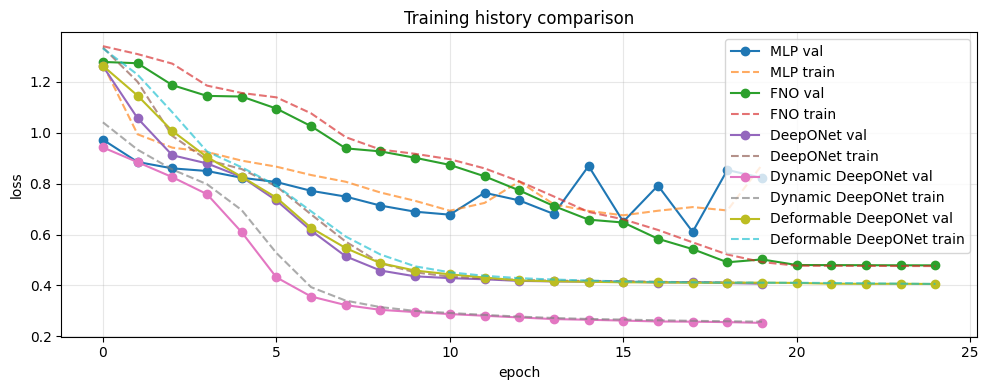

=== Best losses ===
MLP      best train loss: 0.6753780901432037 | best val loss: 0.610351276397705
FNO      best train loss: 0.4761244237422943 | best val loss: 0.47898716628551485
DeepONet best train loss: 0.4089827060699463 | best val loss: 0.40708768665790557
Dynamic DeepONet best train loss: 0.25804529190063474 | best val loss: 0.25328356474637986
Deformable DeepONet best train loss: 0.40618778467178346 | best val loss: 0.4057923823595047


In [21]:
# Cell 11: compare training histories


history_specs = [
    ("MLP", utils.get_or_load_history(globals(), "mlp_history", mlp_checkpoint_name)),
    ("FNO", utils.get_or_load_history(globals(), "fno_history", fno_checkpoint_name)),
    ("DeepONet", utils.get_or_load_history(globals(), "deeponet_history", deeponet_checkpoint_name)),
    ("Dynamic DeepONet", utils.get_or_load_history(globals(), "dynamic_deeponet_history", dynamic_deeponet_checkpoint_name)),
    ("Deformable DeepONet", utils.get_or_load_history(globals(), "deformable_deeponet_history", deformable_deeponet_checkpoint_name)),
]

print("=== Loaded history lengths ===")
for name, history in history_specs:
    print(
        f"{name:8s} "
        f"train={len(utils.history_get(history, 'train_loss')):3d} "
        f"val={len(utils.history_get(history, 'val_loss')):3d} "
        f"train_steps={len(utils.history_get(history, 'step_train_loss')):4d} "
        f"val_steps={len(utils.history_get(history, 'step_val_loss')):4d}"
    )

available_histories = [
    (name, history)
    for name, history in history_specs
    if utils.history_get(history, "train_loss") or utils.history_get(history, "val_loss")
]

if not available_histories:
    print("No training histories are available. Run training cells or load checkpoints with history.")
else:
    plt.figure(figsize=(10, 4))

    for name, history in available_histories:
        val_loss = utils.history_get(history, "val_loss")
        train_loss = utils.history_get(history, "train_loss")
        if val_loss:
            plt.plot(val_loss, marker="o", label=f"{name} val")
        if train_loss:
            plt.plot(train_loss, linestyle="--", alpha=0.65, label=f"{name} train")

    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training history comparison")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("=== Best losses ===")
    for name, history in available_histories:
        val_loss = utils.history_get(history, "val_loss")
        train_loss = utils.history_get(history, "train_loss")
        best_train = min(train_loss) if train_loss else None
        best_val = min(val_loss) if val_loss else None
        print(f"{name:8s} best train loss: {best_train} | best val loss: {best_val}")


### Неожиданная геометрия

In [24]:
# Cell 12: unexpected geometry check

unexpected_geometry_kind = "tube_with_hole"  # "tube_with_hole" or "sharp_bottleneck"



def make_mlp_for_unexpected():
    return ProfileMLP(
        n_profile_points=n_profile_points,
        in_channels=2,
        n_frequencies=n_frequencies,
        hidden_dim=512,
        depth=4,
        dropout=0.05,
        out_channels=1,
    )


def make_fno_for_unexpected():
    return TransferFunctionFNO(
        n_modes=32,
        hidden_channels=96,
        latent_dim=256,
        pooling_bins=16,
        frequency_bands=16,
        out_channels=1,
    )


def make_deeponet_for_unexpected():
    return TransferFunctionDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
    )


def make_dynamic_deeponet_for_unexpected():
    return TransferFunctionDynamicDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        n_experts=4,
        routing_hidden_dim=32,
        temperature=1.0,
    )


def make_deformable_deeponet_for_unexpected():
    return TransferFunctionDeformableDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        max_offset=2.0,
        offset_hidden_channels=32,
    )


unexpected_geometry = utils.make_unexpected_geometry(unexpected_geometry_kind)
unexpected_batch = utils.make_single_geometry_batch(
    unexpected_geometry,
    solver_config,
    geometry_kind=unexpected_geometry_kind,
)

unexpected_models = [
    ("MLP", utils.get_or_load_model(globals(), variable_name="mlp", checkpoint_name=mlp_checkpoint_name, factory=make_mlp_for_unexpected, device=device, verbose=False)[0], mlp_batch_to_xy),
    ("FNO", utils.get_or_load_model(globals(), variable_name="fno", checkpoint_name=fno_checkpoint_name, factory=make_fno_for_unexpected, device=device, verbose=False)[0], fno_batch_to_xy),
    (
        "DeepONet",
        utils.get_or_load_model(globals(), variable_name="deeponet", checkpoint_name=deeponet_checkpoint_name, factory=make_deeponet_for_unexpected, device=device, verbose=False)[0],
        deeponet_batch_to_xy,
    ),
    (
        "Dynamic DeepONet",
        utils.get_or_load_model(globals(), variable_name="dynamic_deeponet", checkpoint_name=dynamic_deeponet_checkpoint_name, factory=make_dynamic_deeponet_for_unexpected, device=device, verbose=False)[0],
        deeponet_batch_to_xy,
    ),
    (
        "Deformable DeepONet",
        utils.get_or_load_model(globals(), variable_name="deformable_deeponet", checkpoint_name=deformable_deeponet_checkpoint_name, factory=make_deformable_deeponet_for_unexpected, device=device, verbose=False)[0],
        deeponet_batch_to_xy,
    ),
]

_, unexpected_target = mlp_batch_to_xy(unexpected_batch, torch.device(device))
unexpected_target = unexpected_target.detach().cpu()

print("unexpected geometry:", unexpected_geometry_kind)
print("target shape:", tuple(unexpected_target.shape))

# Draw geometry once.
plt.figure(figsize=(9, 3.5))
ax = plt.gca()
plot_batch_geometry(
    unexpected_batch,
    0,
    ax,
    title=f"Unexpected geometry: {unexpected_geometry_kind}",
)
plt.tight_layout()
plt.show()

# Separate prediction plot for each available model.
unexpected_predictions = {}
for name, model, batch_to_xy in unexpected_models:
    if model is None:
        continue

    prediction, _ = predict_on_batch(model, batch_to_xy, unexpected_batch)
    unexpected_predictions[name] = prediction
    plot_model_prediction_on_channel(
        unexpected_batch,
        prediction,
        unexpected_target,
        f"{name} on {unexpected_geometry_kind}",
        sample_idx=0,
    )

# Combined plot for quick comparison.
if unexpected_predictions:
    freq = unexpected_batch["frequencies_hz"][0].detach().cpu()
    y = unexpected_target[0]

    plt.figure(figsize=(12, 5))
    plt.plot(freq, y, color="black", linewidth=2.4, label="target cone dB")
    for name, prediction in unexpected_predictions.items():
        plt.plot(freq, prediction[0], linewidth=1.8, alpha=0.85, label=name)

    plt.xlabel("Frequency, Hz")
    plt.ylabel("Transfer function, dB")
    plt.title(f"Unexpected geometry comparison: {unexpected_geometry_kind}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("=== Unexpected geometry metrics ===")
    for name, prediction in unexpected_predictions.items():
        pred = prediction[0]
        mae = torch.mean(torch.abs(pred - y)).item()
        rmse = torch.sqrt(torch.mean((pred - y) ** 2)).item()
        print(f"{name:8s} MAE dB: {mae:8.4f} | RMSE dB: {rmse:8.4f}")
else:
    print("No trained models are available for unexpected-geometry check.")


NameError: name 'mlp_checkpoint_name' is not defined

## Масштабирование

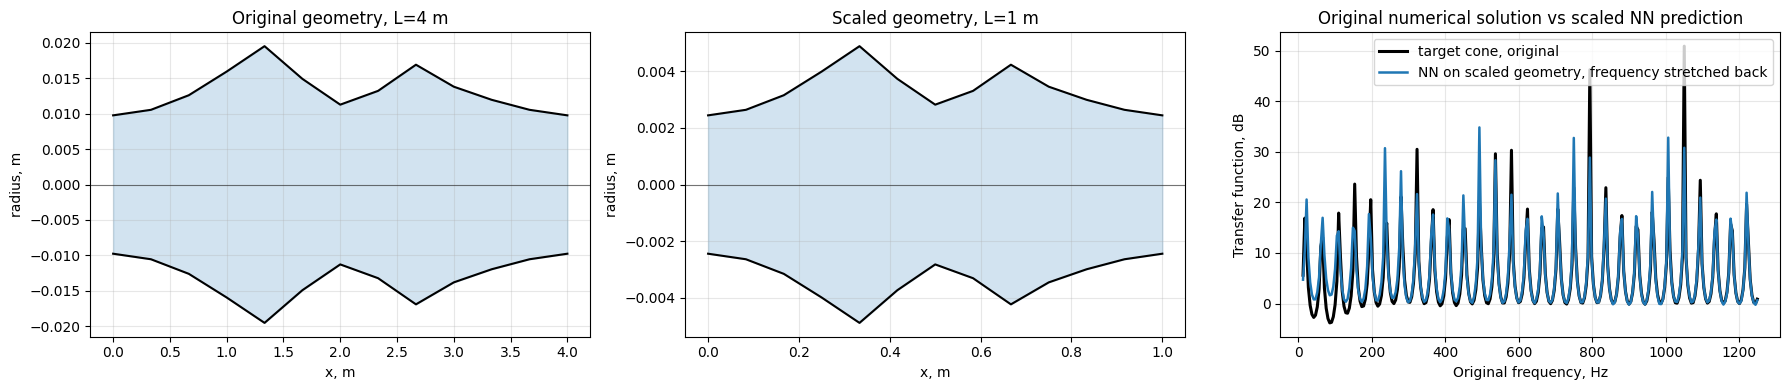

scale_factor: 0.25
original frequency range: 12.5 to 1250.0 Hz
scaled model frequency range: 50.0 to 5000.0 Hz
MAE dB: 1.6560466273683372
RMSE dB: 3.3013653393886395


In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import vt_all_solvers_wrapper as vt
import utils


# ----------------------------
# 1) Choose trained model
# ----------------------------
checkpoint_path = Path("checkpoints") / "deeponet_db_best.pt"
model = TransferFunctionDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)
utils.load_model_state(model, checkpoint["model_state"], strict=True)
model.eval()

batch_to_xy = deeponet_batch_to_xy


# ----------------------------
# 2) Make original 4 m geometry
# ----------------------------

original_length_m = 4.0
scaled_length_m = 1.0
scale_factor = scaled_length_m / original_length_m  # 0.25

x_norm = np.linspace(0.0, 1.0, 13)

# Any profile shape. This is area profile for the 4 m original channel.
original_area_m2 = np.array(
    [
        3.0e-4,
        3.5e-4,
        5.0e-4,
        8.0e-4,
        1.2e-3,
        7.0e-4,
        4.0e-4,
        5.5e-4,
        9.0e-4,
        6.0e-4,
        4.5e-4,
        3.5e-4,
        3.0e-4,
    ],
    dtype=float,
)

original_geometry = vt.ExplicitGeometry(
    x_m=(original_length_m * x_norm).tolist(),
    area_m2=original_area_m2.tolist(),
)

# Full geometric scaling:
# x -> s * x
# area -> s^2 * area
scaled_geometry = vt.ExplicitGeometry(
    x_m=(scale_factor * np.asarray(original_geometry.x_m)).tolist(),
    area_m2=((scale_factor ** 2) * np.asarray(original_geometry.area_m2)).tolist(),
)


# ----------------------------
# 3) Numerical solution on original channel
# ----------------------------

# The original frequency range must map into the model frequency range.
# If model was trained on 50..5000 Hz and scale_factor=0.25,
# original frequencies 12.5..1250 Hz map to scaled frequencies 50..5000 Hz.
original_solver_config = vt.SolverConfig(
    solver="cone",
    sections=100,
    points=n_frequencies,
    f_min_hz=scale_factor * solver_config.f_min_hz,
    f_max_hz=scale_factor * solver_config.f_max_hz,
    grid="linear",
    beta_loss_np_per_m=0.0,
)

original_result = vt.solve(
    original_geometry,
    config=original_solver_config,
)

freq_original = np.asarray(original_result.frequencies_hz, dtype=float)
target_original_db = 20.0 * np.log10(
    np.maximum(np.asarray(original_result.magnitude, dtype=float), 1e-12)
)


# ----------------------------
# 4) Neural prediction on scaled channel
# ----------------------------

freq_scaled = freq_original / scale_factor

x_m, area_m2, segment_lengths_m = vt.geometry_to_tube_tuple(scaled_geometry)

scaled_batch = {
    "target": torch.zeros(1, len(freq_scaled), dtype=torch.float32),
    "frequencies_hz": torch.tensor(freq_scaled, dtype=torch.float32).unsqueeze(0),
    "geometry": {
        "x_m": torch.tensor([x_m], dtype=torch.float32),
        "area_m2": torch.tensor([area_m2], dtype=torch.float32),
        "segment_lengths_m": torch.tensor([segment_lengths_m], dtype=torch.float32),
        "node_count": torch.tensor([len(x_m)], dtype=torch.int64),
        "segment_count": torch.tensor([len(segment_lengths_m)], dtype=torch.int64),
    },
}

with torch.no_grad():
    prediction_scaled, _ = utils.predict(
        model,
        [scaled_batch],
        batch_to_xy=batch_to_xy,
        device=device,
        show_progress=False,
    )

pred_original_db = prediction_scaled[0].detach().cpu().numpy()


# ----------------------------
# 5) Plot comparison
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

vt.plot_geometry(
    original_geometry,
    mode="symmetric",
    equal_aspect=False,
    linewidth=1.5,
    ax=axes[0],
    title=f"Original geometry, L={original_length_m:g} m",
)
axes[0].grid(True, alpha=0.3)

vt.plot_geometry(
    scaled_geometry,
    mode="symmetric",
    equal_aspect=False,
    linewidth=1.5,
    ax=axes[1],
    title=f"Scaled geometry, L={scaled_length_m:g} m",
)
axes[1].grid(True, alpha=0.3)

axes[2].plot(freq_original, target_original_db, linewidth=2.2, color="black", label="target cone, original")
axes[2].plot(freq_original, pred_original_db, linewidth=1.8, label="NN on scaled geometry, frequency stretched back")
axes[2].set_xlabel("Original frequency, Hz")
axes[2].set_ylabel("Transfer function, dB")
axes[2].set_title("Original numerical solution vs scaled NN prediction")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

mae = np.mean(np.abs(pred_original_db - target_original_db))
rmse = np.sqrt(np.mean((pred_original_db - target_original_db) ** 2))

print("scale_factor:", scale_factor)
print("original frequency range:", freq_original[0], "to", freq_original[-1], "Hz")
print("scaled model frequency range:", freq_scaled[0], "to", freq_scaled[-1], "Hz")
print("MAE dB:", mae)
print("RMSE dB:", rmse)

## Чувствителность к геометрии

In [23]:
import torch

# Choose model and adapter.
model = dynamic_deeponet                  # fno / deeponet / dynamic_deeponet / deformable_deeponet
batch_to_xy = fno_batch_to_xy # fno_batch_to_xy or deeponet_batch_to_xy

model = model.to(device)
model.eval()

batch = next(iter(val_loader))

inputs, target = batch_to_xy(batch, torch.device(device))

if isinstance(inputs, tuple):
    area, kappa = inputs
else:
    raise TypeError(
        "This sensitivity block expects an operator model with inputs = (area, kappa). "
        "Use FNO / DeepONet / Dynamic DeepONet / Deformable DeepONet."
    )

with torch.no_grad():
    prediction = model(area, kappa)

    permutation = torch.randperm(
        area.shape[0],
        device=area.device,
    )

    shuffled_prediction = model(
        area[permutation],
        kappa,
    )

sensitivity_abs = torch.mean(
    torch.abs(prediction - shuffled_prediction)
)

sensitivity_rmse = torch.sqrt(
    torch.mean((prediction - shuffled_prediction) ** 2)
)

output_scale = torch.mean(torch.abs(prediction)).clamp_min(1e-12)
relative_sensitivity = sensitivity_abs / output_scale

print("Permutation:", permutation.detach().cpu().tolist())
print("Geometry sensitivity MAE:", sensitivity_abs.item())
print("Geometry sensitivity RMSE:", sensitivity_rmse.item())
print("Relative geometry sensitivity:", relative_sensitivity.item())

Permutation: [30, 22, 6, 26, 11, 27, 9, 3, 14, 20, 7, 17, 28, 12, 5, 0, 31, 29, 2, 15, 16, 18, 1, 23, 4, 25, 8, 19, 21, 13, 10, 24]
Geometry sensitivity MAE: 9.379850387573242
Geometry sensitivity RMSE: 14.5445556640625
Relative geometry sensitivity: 0.9027758240699768
